In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [ ]:
store = pd.HDFStore("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/val.h5")
print(store.keys())
store.close()

['/', '/table']


In [ ]:
initial_data = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/val.h5", key="/table")
# col: E_i | PX_i | PY_i | PZ_i | ... | truthE | truthPX | truthPY | truthPZ | ttv | is_signal_new
#                                           (truth top four-momentum)   (test/train/val) (1=top / 0=QCD)

In [11]:
test = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/train_pT_eta_phi.h5", key="df")

In [10]:
t = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/train_discrete_pT_eta_phi.h5", key="df")

In [12]:
QCD = test[test['is_signal_new'] == 0].copy()
top = test[test['is_signal_new'] == 1].copy()

In [13]:
QCD_eta_0 = QCD.filter(like='delta_eta_').to_numpy(dtype=float)
QCD_eta = QCD_eta_0[np.isfinite(QCD_eta_0)]

QCD_phi_0 = QCD.filter(like='delta_phi_').to_numpy(dtype=float)
QCD_phi = QCD_phi_0[np.isfinite(QCD_phi_0)]

QCD_pT_0 = QCD.filter(like='pT_').to_numpy(dtype=float)
QCD_pT = QCD_pT_0[np.isfinite(QCD_pT_0)]

n_particles_QCD = np.isfinite(QCD_eta_0).sum(axis=1)

top_eta_0 = top.filter(like='delta_eta_').to_numpy(dtype=float)
top_eta = top_eta_0[np.isfinite(top_eta_0)]

top_phi_0 = top.filter(like='delta_phi_').to_numpy(dtype=float)
top_phi = top_phi_0[np.isfinite(top_phi_0)]

top_pT_0 = top.filter(like='pT_').to_numpy(dtype=float)
top_pT = top_pT_0[np.isfinite(top_pT_0)]

n_particles_top = np.isfinite(top_eta_0).sum(axis=1)


In [14]:
consituent_position_counts_QCD = (~np.isnan(QCD_pT_0)).sum(axis=0).astype(int)
consituent_position_counts_top = (~np.isnan(top_pT_0)).sum(axis=0).astype(int)

In [15]:
print(consituent_position_counts_QCD)

[605523 605520 605513 605502 605489 605457 605365 605190 604829 604173
 603159 601571 599402 596318 592466 587666 581897 575203 567647 559282
 550104 540588 530450 519917 508832 497564 485925 474249 462337 449894
 437242 424816 412078 399138 386106 373248 360224 347069 334253 321294
 308670 296158 283780 271733 259689 248083 236442 225221 214136 203242
 193012 183003 173264 163760 154557 145889 137496 129385 121650 114416
 107309 100507  94058  87963  82101  76460  71285  66490  61922  57610
  53359  49411  45730  42362  39203  36258  33534  30890  28349  26067
  23829  21849  19922  18203  16611  15196  13945  12644  11518  10435
   9466   8592   7764   7054   6342   5758   5208   4700   4185   3797
   3415   3038   2705   2422   2144   1911   1672   1493   1328   1187
   1055    924    808    701    618    531    464    407    356    325
    273    237    203    186    163    147    127    109     91     78
     68     62     53     45     39     32     28     26     22     18
     1

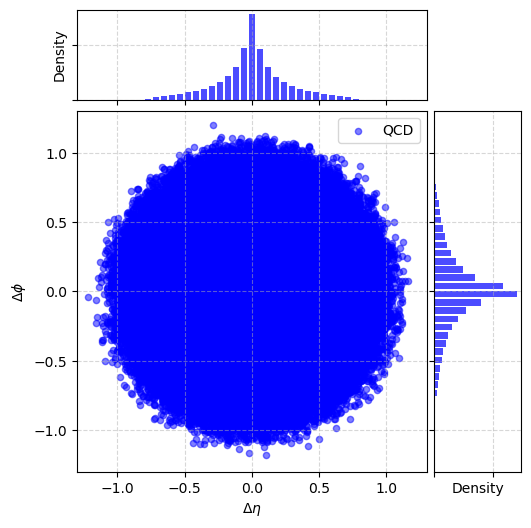

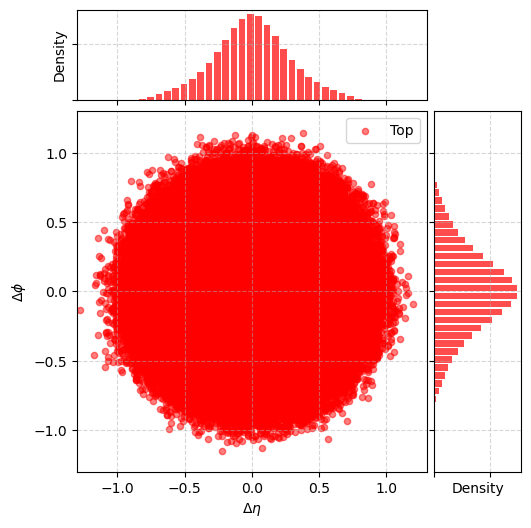

In [16]:

def plot_scatter_with_marginals(x, y, z,
                                hist_bins=40,
                                figsize=(10, 8),
                                scatter_s=10,
                                scatter_alpha=0.5,
                                color="blue",
                                legend="QCD"):
  
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    if not (x.shape == y.shape == z.shape):
        raise ValueError("x, y und z müssen die gleiche Form/Länge haben.")

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 3,
        width_ratios=[4, 1, 0.15],   # Hauptplot, y-Histogramm, Colorbar
        height_ratios=[1, 4],       # x-Histogramm, Hauptplot
        hspace=0.05,
        wspace=0.05
    )

    # Achsen
    ax_histx = fig.add_subplot(gs[0, 0])
    ax_main  = fig.add_subplot(gs[1, 0])
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)
    #ax_cbar  = fig.add_subplot(gs[:, 2])


    # Oberes Histogramm (x)
    ax_histx.hist(x, bins=hist_bins, rwidth=0.8, density=True, color=color, alpha = 0.7)
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histx.tick_params(axis="y", labelleft=False)
    # optional: keine yticks oben
    ax_histx.set_ylabel("Density")

    # Rechtes Histogramm (y)
    ax_histy.hist(y, bins=hist_bins, orientation="horizontal", rwidth=0.8, density=True, color=color, alpha = 0.7)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.tick_params(axis="x", labelbottom=False)
    ax_histy.set_xlabel("Density")

    # Hauptplot: 2D-Heatmap gewichtet mit z
    # hist2d gibt: H, xedges, yedges, image
    #hb = ax_main.hist2d(x, y, bins=bins, weights=z, cmap=cmap)
    #hb = ax_main.hist2d(x, y, bins=bins)
    # Scatter darüber
    ax_main.scatter(x, y, s=scatter_s, alpha=scatter_alpha, color=color)

    ax_main.set_xlabel(r"$\Delta \eta$")
    ax_main.set_ylabel(r"$\Delta \phi$")
    ax_main.set_xlim(-1.3,1.3)
    ax_main.set_ylim(-1.3,1.3)

    # Colorbar ganz rechts
    #cb = fig.colorbar(hb[3], cax=ax_cbar, shrink=0.1)
    #cb.set_label(r"$p_T$")

    # Feinheiten: Achsenränder vereinheitlichen
    ax_histx.set_xlim(ax_main.get_xlim())
    ax_histy.set_ylim(ax_main.get_ylim())

    ax_histx.grid(True, linestyle='--', alpha=0.5)
    ax_histy.grid(True, linestyle='--', alpha=0.5)
    ax_main.grid(True, linestyle='--', alpha=0.5)

    ax_main.legend([legend], loc='upper right')

    # Optional: leichte Randausräumung
    #plt.tight_layout()
    plt.show()
    return


plot_scatter_with_marginals(QCD_eta, QCD_phi, np.log(QCD_pT), hist_bins=40, figsize=(6, 6), scatter_s=20, scatter_alpha=0.5, color='blue', legend='QCD')
plot_scatter_with_marginals(top_eta, top_phi, np.log(top_pT), hist_bins=40, figsize=(6, 6), scatter_s=20, scatter_alpha=0.5, color='red', legend='Top')

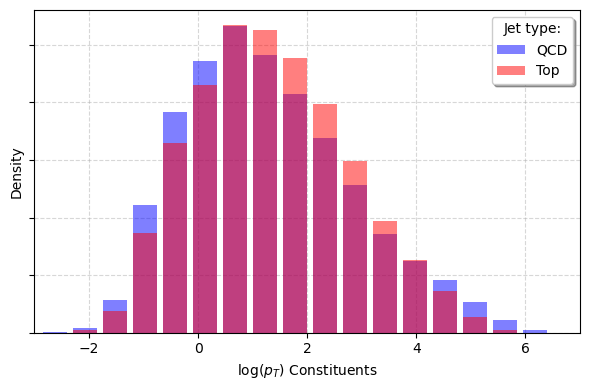

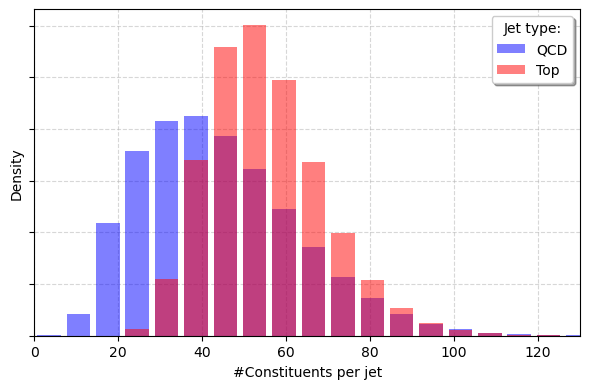

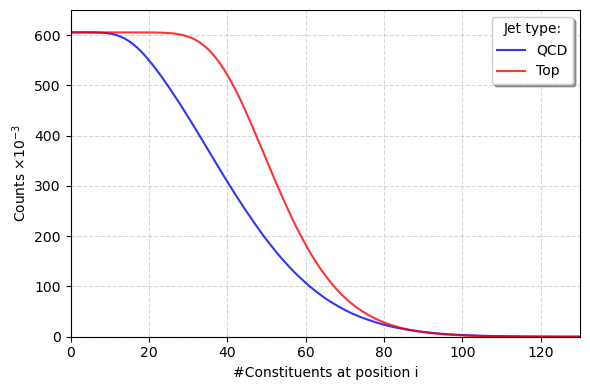

In [21]:
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.hist(np.log(QCD_pT), bins=20, alpha=0.5, label='QCD', density=True, color="blue", rwidth=0.8, range=(-4, 7))
ax1.hist(np.log(top_pT), bins=20, alpha=0.5, label='Top', density=True, color="red", rwidth=0.8, range=(-4, 7))
ax1.set_xlabel(r'$\log(p_T)$ Constituents')
ax1.set_ylabel('Density')
ax1.legend(loc='upper right', shadow=True, title="Jet type:")
ax1.grid(True, linestyle='--', alpha=0.5) 
ax1.set_axisbelow(True)
ax1.set_xlim(-3, 7)
ax1.tick_params(labelleft=False)
plt.tight_layout()
plt.show()

fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.hist(n_particles_QCD, bins=20, alpha=0.5, label='QCD', density=True, color="blue", rwidth=0.8, range=(0, 140))
ax1.hist(n_particles_top, bins=20, alpha=0.5, label='Top', density=True, color="red", rwidth=0.8, range=(0, 140))
ax1.set_xlabel('#Constituents per jet')
ax1.set_ylabel('Density')
ax1.legend(loc='upper right', shadow=True, title="Jet type:")
ax1.grid(True, linestyle='--', alpha=0.5) 
ax1.set_axisbelow(True)
ax1.set_xlim(0, 130)
ax1.tick_params(labelleft=False)
plt.tight_layout()
plt.show()

fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(range(len(consituent_position_counts_QCD)), consituent_position_counts_QCD*10**(-3), alpha=0.8, label='QCD', color="blue")
ax1.plot(range(len(consituent_position_counts_top)), consituent_position_counts_top*10**(-3), alpha=0.8, label='Top', color="red")
ax1.set_xlabel('#Constituents at position i')
ax1.set_ylabel(r'Counts $\times 10^{-3}$')
ax1.legend(loc='upper right', shadow=True, title="Jet type:")
ax1.grid(True, linestyle='--', alpha=0.5) 
ax1.set_axisbelow(True)
ax1.set_xlim(0, 130)
ax1.set_ylim(0, 650)
#ax1.tick_params(labelleft=False)
plt.tight_layout()
plt.show()

In [22]:
top_discrete_data = t[t["is_signal_new"] == 1].copy()
QCD_discrete_data = t[t["is_signal_new"] == 0].copy()

In [23]:
def count_unique_discretetized_states_per_position(df: pd.DataFrame, n_positions: int = 200) -> np.ndarray:
    counts = np.zeros(n_positions, dtype=int)
    for i in range(n_positions):
        cols = [f"pT_bin_{i}", f"eta_bin_{i}", f"phi_bin_{i}"]
        if not all(c in df.columns for c in cols):
            continue
        mask = df[cols].notna().all(axis=1) & ~((df[cols] == -1).all(axis=1))
        counts[i] = df.loc[mask, cols].apply(tuple, axis=1).nunique()
    return counts

unique_states_top = count_unique_discretetized_states_per_position(top_discrete_data)

In [24]:
unique_states_QCD = count_unique_discretetized_states_per_position(QCD_discrete_data)

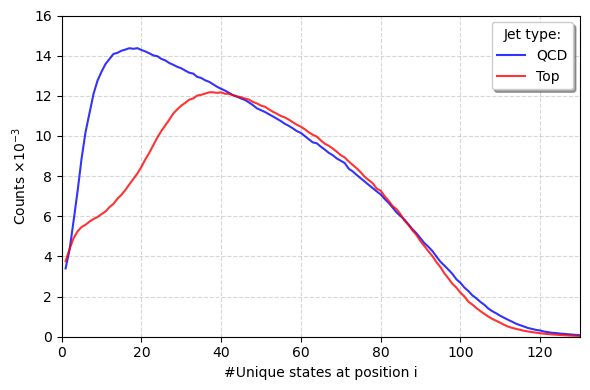

In [26]:
x = np.arange(1,201)

fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(x, unique_states_QCD*10**(-3), alpha=0.8, label='QCD', color="blue")
ax1.plot(x, unique_states_top*10**(-3), alpha=0.8, label='Top', color="red")
ax1.set_xlabel('#Unique states at position i')
ax1.set_ylabel(r'Counts $\times 10^{-3}$')
ax1.legend(loc='upper right', shadow=True, title="Jet type:")
ax1.grid(True, linestyle='--', alpha=0.5) 
ax1.set_axisbelow(True)
ax1.set_xlim(0, 130)
ax1.set_ylim(0, 16)
#ax1.tick_params(labelleft=False)
plt.tight_layout()
plt.show()

In [27]:
import re
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import torch.nn.functional as F
from typing import Tuple

In [43]:
train_data_0 = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/train_discrete_pT_eta_phi.h5", key="df")
val_data_0 = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/val_discrete_pT_eta_phi.h5", key="df")
test_data_0 = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/test_discrete_pT_eta_phi.h5", key="df")

In [44]:
train_data = train_data_0[train_data_0["is_signal_new"] == 0].copy().head(10)
val_data = val_data_0[val_data_0["is_signal_new"] == 0].copy().head(10)
test_data = test_data_0[test_data_0["is_signal_new"] == 0].copy().head(10)

In [45]:
# --------------------------
# DF -> Tensors
# --------------------------
def df_to_bin_tensors(df: pd.DataFrame, max_particles: int = 200, device: torch.device = torch.device('cpu')) -> Tuple[torch.LongTensor, torch.LongTensor, torch.LongTensor, torch.LongTensor]:
    """
    Liefert pT, eta, phi Tensors (B, N) mit -1 als originalem Padding.
    counts: Anzahl realer Teilchen pro Event (geclippt auf max_particles).
    Optimierungen:
      - iteriere nur über vorhandene Spalten bis max_particles
      - vermeide unnötige Zwischenschritte
    """
    pattern = re.compile(r'^(pT|eta|phi)_bin_(\d+)$')
    # Sammle vorhandene Indices pro Prefix
    present_idxs = set()
    for col in df.columns:
        m = pattern.match(col)
        if m:
            present_idxs.add(int(m.group(2)))
    if present_idxs:
        max_present = max(present_idxs)
    else:
        max_present = -1

    B = len(df)
    N = max_particles

    # prepare arrays with -1
    pT_arr = np.full((B, N), -1, dtype=np.int64)
    eta_arr = np.full((B, N), -1, dtype=np.int64)
    phi_arr = np.full((B, N), -1, dtype=np.int64)

    # Only loop over indices actually present (and < N)
    for j in sorted(present_idxs):
        if j >= N:
            break
        pt_col = f"pT_bin_{j}"
        if pt_col in df.columns:
            pT_arr[:, j] = df[pt_col].fillna(-1).astype(np.int64).values
        eta_col = f"eta_bin_{j}"
        if eta_col in df.columns:
            eta_arr[:, j] = df[eta_col].fillna(-1).astype(np.int64).values
        phi_col = f"phi_bin_{j}"
        if phi_col in df.columns:
            phi_arr[:, j] = df[phi_col].fillna(-1).astype(np.int64).values

    # counts: zähle real vorhandene pT-Spalten (bis max_present, aber clippe auf N)
    if max_present >= 0:
        # Count non -1 across available pT columns up to N
        available = [f"pT_bin_{j}" for j in range(min(max_present + 1, N)) if f"pT_bin_{j}" in df.columns]
        if available:
            stacked = np.stack([df[c].fillna(-1).astype(np.int64).values for c in available], axis=1)  # (B, M)
            counts = np.sum(stacked != -1, axis=1).astype(np.int64)
        else:
            counts = np.zeros(B, dtype=np.int64)
    else:
        counts = np.zeros(B, dtype=np.int64)

    counts = np.minimum(counts, N)

    # to tensors
    pT_t = torch.from_numpy(pT_arr).long().to(device)
    eta_t = torch.from_numpy(eta_arr).long().to(device)
    phi_t = torch.from_numpy(phi_arr).long().to(device)
    counts_t = torch.from_numpy(counts).long().to(device)

    return pT_t, eta_t, phi_t, counts_t

pT_train, eta_train, phi_train, counts_train = df_to_bin_tensors(train_data, max_particles=100)
pT_val, eta_val, phi_val, counts_val = df_to_bin_tensors(val_data, max_particles=100)
pT_test, eta_test, phi_test, counts_test = df_to_bin_tensors(test_data, max_particles=100)

In [ ]:

# --------------------------
# Embedder (leicht angepasst)
# --------------------------
class ParticleEmbedder(nn.Module):
    def __init__(self,
                 emb_dim: int = 256,
                 pT_max_value: int = 40,
                 eta_max_value: int = 30,
                 phi_max_value: int = 30,
                 max_particles: int = 100,
                 use_position_embedding: bool = False,
                 dropout: float = 0.0):
        super().__init__()
        self.emb_dim = emb_dim
        self.max_particles = max_particles
        self.S = 1 + max_particles + 1  # START + N + STOP

        # +2 um "-1 -> 0 (padding)" und Werte bis max_value inclusive abzudecken
        self.pT_emb = nn.Embedding(num_embeddings=pT_max_value + 2, embedding_dim=emb_dim, padding_idx=0)
        self.eta_emb = nn.Embedding(num_embeddings=eta_max_value + 2, embedding_dim=emb_dim, padding_idx=0)
        self.phi_emb = nn.Embedding(num_embeddings=phi_max_value + 2, embedding_dim=emb_dim, padding_idx=0)

        self.use_position_embedding = use_position_embedding
        if use_position_embedding:
            # Indices 1..N verwendet
            self.pos_emb = nn.Embedding(max_particles + 1, emb_dim)

        self.start_token = nn.Parameter(torch.randn(emb_dim) * 0.02)
        self.stop_token = nn.Parameter(torch.randn(emb_dim) * 0.02)

        self.layernorm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

    def forward(self, pT_bins: torch.LongTensor, eta_bins: torch.LongTensor, phi_bins: torch.LongTensor, counts: torch.LongTensor) -> torch.FloatTensor:
        """
        pT_bins, eta_bins, phi_bins: (B, max_particles) with -1 for padded slots
        counts: (B,) with number of real particles (should be <= max_particles)
        returns seq: (B, S, D)
        """
        B, N = pT_bins.shape
        assert N == self.max_particles
        device = pT_bins.device
        D = self.emb_dim
        S = self.S

        # map -1 -> 0, clamp upper bound
        pT_idx = torch.clamp(pT_bins + 1, min=0, max=self.pT_emb.num_embeddings - 1)
        eta_idx = torch.clamp(eta_bins + 1, min=0, max=self.eta_emb.num_embeddings - 1)
        phi_idx = torch.clamp(phi_bins + 1, min=0, max=self.phi_emb.num_embeddings - 1)

        e_pT = self.pT_emb(pT_idx)
        e_eta = self.eta_emb(eta_idx)
        e_phi = self.phi_emb(phi_idx)
        e_particles = e_pT + e_eta + e_phi

        # NOTE: positions added before scatter would need remapping; we keep pos_emb optional and
        # apply it on original ordered slots (1..N) which are later scattered into seq
        if self.use_position_embedding:
            pos_idx = torch.arange(1, N + 1, device=device).unsqueeze(0).expand(B, N)
            e_particles = e_particles + self.pos_emb(pos_idx)

        seq = torch.zeros((B, S, D), dtype=e_particles.dtype, device=device)
        seq[:, 0, :] = self.start_token.view(1, D)

        arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
        counts_exp = counts.unsqueeze(1).expand(B, N)
        shift = (arange >= counts_exp).long()
        dest = 1 + arange + shift  # (B, N) in [1..N+1]

        # scatter particle embeddings into final sequence
        dest_idx = dest.unsqueeze(-1).expand(B, N, D)
        seq = seq.scatter(dim=1, index=dest_idx, src=e_particles)

        # Stop token where needed
        stop_needed = (counts < N)
        if stop_needed.any():
            stop_pos = (1 + counts).to(torch.long)
            batch_idx = torch.arange(B, device=device)
            seq[batch_idx[stop_needed], stop_pos[stop_needed], :] = self.stop_token.view(1, D)

        seq = self.layernorm(seq)
        seq = self.dropout(seq)
        return seq

    def make_masks(self, pT_bins: torch.LongTensor, counts: torch.LongTensor) -> Tuple[torch.BoolTensor, torch.BoolTensor]:
        """
        Returns:
            src_key_padding_mask: (B, S) bool, True = padding (ignored)
            causal_mask: (S, S) bool, True = mask (i.e. block attention)
        """
        B, N = pT_bins.shape
        device = pT_bins.device
        S = self.S

        orig_pad = (pT_bins == -1)  # True = padding in original slots

        arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
        counts_exp = counts.unsqueeze(1).expand(B, N)
        shift = (arange >= counts_exp).long()
        dest = 1 + arange + shift  # (B,N)

        # start with everything masked (True) and unmask START and real tokens
        src_key_padding_mask = torch.ones((B, S), dtype=torch.bool, device=device)
        src_key_padding_mask[:, 0] = False  # START not masked

        batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(B, N)

        # unmask positions that correspond to real (non-padded) original slots
        real_mask = ~orig_pad
        src_key_padding_mask[batch_idx[real_mask], dest[real_mask]] = False

        # ensure padded original slots remain masked (redundant)
        src_key_padding_mask[batch_idx[orig_pad], dest[orig_pad]] = True

        # unmask STOP if present
        stop_needed = (counts < N)
        if stop_needed.any():
            stop_pos = (1 + counts)
            batch_idx_simple = torch.arange(B, device=device)
            src_key_padding_mask[batch_idx_simple[stop_needed], stop_pos[stop_needed]] = False

        # causal mask: mask future tokens (diagonal=1 so tokens can see themselves)
        causal_mask = torch.triu(torch.ones((S, S), dtype=torch.bool, device=device), diagonal=0)
        return src_key_padding_mask, causal_mask


# --------------------------
# Transformer
# --------------------------
class ParticleTransformer(nn.Module):
    def __init__(self,
                 num_pT_embeddings: int = 42,   # num_bins + 1 for padding
                 num_eta_embeddings: int = 32,
                 num_phi_embeddings: int = 32,
                 emb_dim: int = 256,
                 n_layers: int = 8,
                 n_heads: int = 4,
                 dim_feedforward: int = None,
                 dropout: float = 0.1,
                 pad_token: int = 0):
        super().__init__()
        self.emb_dim = emb_dim
        self.pad_token = pad_token
        if dim_feedforward is None:
            dim_feedforward = emb_dim * 4

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim,
                                                   nhead=n_heads,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout,
                                                   activation='relu',
                                                   batch_first=True)  # now batch first
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, norm=nn.LayerNorm(emb_dim))

        self.final_norm = nn.LayerNorm(emb_dim)
        self.final_dropout = nn.Dropout(dropout)

        self.type_head = nn.Linear(emb_dim, 3)  # Klassifikation: START, PARTICLE, STOP
        self.head_pT  = nn.Linear(emb_dim, num_pT_embeddings)
        self.head_eta = nn.Linear(emb_dim, num_eta_embeddings)
        self.head_phi = nn.Linear(emb_dim, num_phi_embeddings)


    def forward(self,
                seq_emb: torch.FloatTensor,
                src_key_padding_mask: torch.BoolTensor,
                causal_mask: torch.BoolTensor):
        """
        seq_emb: (B, S, D)
        src_key_padding_mask: (B, S) bool True = padding
        causal_mask: (S, S) bool True = mask (block)
        returns logits_type, logits_pT, logits_eta, logits_phi
        """
        B, S, D = seq_emb.shape
        assert D == self.emb_dim

        # Use boolean masks for both causal mask and src_key_padding_mask to avoid dtype mismatch warning.
        # causal_mask: (S,S) bool, True = mask (block future tokens)
        attn_mask = causal_mask.to(dtype=seq_emb.dtype) * -1e9  # shape (S, S), float

        # encoder expects batch_first=True -> (B,S,D)
        enc = self.encoder(seq_emb, mask=attn_mask, src_key_padding_mask=src_key_padding_mask)
        enc = self.final_norm(enc)
        enc = self.final_dropout(enc)
    
        logits_type = self.type_head(enc)  # (B, S, 3)
        logits_pT  = self.head_pT(enc)   # (B, S, num_pT_embeddings)
        logits_eta = self.head_eta(enc)  # (B, S, num_eta_embeddings)
        logits_phi = self.head_phi(enc)  # (B, S, num_phi_embeddings)
        
        return logits_type, logits_pT, logits_eta, logits_phi


# --------------------------
# Helper: prepare batch for train/test mode
# --------------------------
def prepare_batch_for_mode(pT_full: torch.LongTensor,
                           eta_full: torch.LongTensor,
                           phi_full: torch.LongTensor,
                           counts_full: torch.LongTensor,
                           mode: str = "train",
                           train_max_real: int = 50,
                           max_particles: int = 100) -> Tuple[torch.LongTensor, torch.LongTensor, torch.LongTensor, torch.LongTensor]:
    """
    pT_full, eta_full, phi_full: (B, max_particles) raw data (may contain real particles up to max_particles)
    counts_full: (B,) real counts per example (<= max_particles)
    mode: "train" -> truncate to first train_max_real particles, pad rest with -1
          "test"  -> use full max_particles
    Returns pT_bins, eta_bins, phi_bins, counts (all shaped for the embedder: (B, max_particles), counts (B,))
    """
    assert mode in ("train", "test")
    B, N = pT_full.shape
    assert N == max_particles

    device = pT_full.device

    if mode == "test":
        # pass-through: use everything (no truncation)
        return pT_full.clone(), eta_full.clone(), phi_full.clone(), counts_full.clone()

    # mode == "train": truncate real particles at train_max_real and pad rest with -1
    tm = int(train_max_real)
    assert tm <= max_particles, "train_max_real must be <= max_particles"

    # create padded tensors
    pT_out = torch.full((B, max_particles), -1, dtype=pT_full.dtype, device=device)
    eta_out = torch.full((B, max_particles), -1, dtype=eta_full.dtype, device=device)
    phi_out = torch.full((B, max_particles), -1, dtype=phi_full.dtype, device=device)

    # copy first tm slots (if available) from full input
    pT_out[:, :tm] = pT_full[:, :tm]
    eta_out[:, :tm] = eta_full[:, :tm]
    phi_out[:, :tm] = phi_full[:, :tm]

    # clamp counts to tm (if original had more than tm, we drop extras for training)
    counts_out = torch.clamp(counts_full, max=tm)

    return pT_out, eta_out, phi_out, counts_out


# --------------------------
# Example usage
# --------------------------
if __name__ == "__main__":

    max_particles = 100
    train_max = 50

    embedder = ParticleEmbedder(max_particles=max_particles)
    transformer = ParticleTransformer()

    # TRAINING mode: truncate to first train_max real particles per Jet
    pT_train, eta_train, phi_train, counts_train = prepare_batch_for_mode(pT_train, eta_train, phi_train, counts_train, mode="train", train_max_real=train_max, max_particles=max_particles)
    seq_train = embedder(pT_train, eta_train, phi_train, counts_train)
    src_mask_train, causal_train = embedder.make_masks(pT_train, counts_train)
    logits_type, logits_pT, logits_eta, logits_phi = transformer(seq_train, src_mask_train, causal_train)

    pT_val, eta_val, phi_val, counts_val = prepare_batch_for_mode(pT_val, eta_val, phi_val, counts_val, mode="train", train_max_real=train_max, max_particles=max_particles)
    seq_val = embedder(pT_val, eta_val, phi_val, counts_val)
    src_mask_val, causal_val = embedder.make_masks(pT_val, counts_val)
    logits_type_val, logits_pT_val, logits_eta_val, logits_phi_val = transformer(seq_val, src_mask_val, causal_val)


    # TEST mode: use 100 real particles per Jet
    pT_test, eta_test, phi_test, counts_test = prepare_batch_for_mode(pT_test, eta_test, phi_test, counts_test, mode="test", max_particles=max_particles)
    seq_test = embedder(pT_test, eta_test, phi_test, counts_test)
    src_mask_test, causal_test = embedder.make_masks(pT_test, counts_test)
    logits_type_test, logits_pT_test, logits_eta_test, logits_phi_test = transformer(seq_test, src_mask_test, causal_test)



/home/ew640340/miniforge3/envs/Test1/lib/python3.11/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


Train seq shape: torch.Size([10, 102, 256]) mask shape: torch.Size([10, 102])
Test seq shape: torch.Size([10, 102, 256]) mask shape: torch.Size([10, 102])


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from typing import Tuple
import re

import os
import math
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import warnings

In [2]:
train_data = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/QCD_train_discrete_pT_eta_phi.h5", key="df").head(100)
val_data = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/QCD_val_discrete_pT_eta_phi.h5", key="df").head(100)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------
# DF -> Tensors
# --------------------------
def df_to_bin_tensors(df: pd.DataFrame, max_particles: int = 200, device: torch.device = device) -> Tuple[torch.LongTensor, torch.LongTensor, torch.LongTensor, torch.LongTensor]:
    """
    Liefert pT, eta, phi Tensors (B, N) mit -1 als originalem Padding.
    counts: Anzahl realer Teilchen pro Event (geclippt auf max_particles).
    Optimierungen:
      - iteriere nur über vorhandene Spalten bis max_particles
      - vermeide unnötige Zwischenschritte
    """
    pattern = re.compile(r'^(pT|eta|phi)_bin_(\d+)$')
    # Sammle vorhandene Indices pro Prefix
    present_idxs = set()
    for col in df.columns:
        m = pattern.match(col)
        if m:
            present_idxs.add(int(m.group(2)))
    if present_idxs:
        max_present = max(present_idxs)
    else:
        max_present = -1

    B = len(df)
    N = max_particles

    # prepare arrays with -1
    pT_arr = np.full((B, N), -1, dtype=np.int64)
    eta_arr = np.full((B, N), -1, dtype=np.int64)
    phi_arr = np.full((B, N), -1, dtype=np.int64)

    # Only loop over indices actually present (and < N)
    for j in sorted(present_idxs):
        if j >= N:
            break
        pt_col = f"pT_bin_{j}"
        if pt_col in df.columns:
            pT_arr[:, j] = df[pt_col].fillna(-1).astype(np.int64).values
        eta_col = f"eta_bin_{j}"
        if eta_col in df.columns:
            eta_arr[:, j] = df[eta_col].fillna(-1).astype(np.int64).values
        phi_col = f"phi_bin_{j}"
        if phi_col in df.columns:
            phi_arr[:, j] = df[phi_col].fillna(-1).astype(np.int64).values

    # counts: zähle real vorhandene pT-Spalten (bis max_present, aber clippe auf N)
    if max_present >= 0:
        # Count non -1 across available pT columns up to N
        available = [f"pT_bin_{j}" for j in range(min(max_present + 1, N)) if f"pT_bin_{j}" in df.columns]
        if available:
            stacked = np.stack([df[c].fillna(-1).astype(np.int64).values for c in available], axis=1)  # (B, M)
            counts = np.sum(stacked != -1, axis=1).astype(np.int64)
        else:
            counts = np.zeros(B, dtype=np.int64)
    else:
        counts = np.zeros(B, dtype=np.int64)

    counts = np.minimum(counts, N)

    # to tensors
    pT_t = torch.from_numpy(pT_arr).long().to(device)
    eta_t = torch.from_numpy(eta_arr).long().to(device)
    phi_t = torch.from_numpy(phi_arr).long().to(device)
    counts_t = torch.from_numpy(counts).long().to(device)

    return pT_t, eta_t, phi_t, counts_t


# --------------------------
# Embedder
# --------------------------
class ParticleEmbedder(nn.Module):
    def __init__(self,
                 emb_dim: int = 256,
                 pT_max_value: int = 40,
                 eta_max_value: int = 30,
                 phi_max_value: int = 30,
                 max_particles: int = 100,
                 use_position_embedding: bool = False,
                 dropout: float = 0.0):
        super().__init__()
        self.emb_dim = emb_dim
        self.max_particles = max_particles
        self.S = 1 + max_particles + 1  # START + N + STOP

        # +2 um "-1 -> 0 (padding)" und Werte bis max_value inclusive abzudecken
        self.pT_emb = nn.Embedding(num_embeddings=pT_max_value + 2, embedding_dim=emb_dim, padding_idx=0)
        self.eta_emb = nn.Embedding(num_embeddings=eta_max_value + 2, embedding_dim=emb_dim, padding_idx=0)
        self.phi_emb = nn.Embedding(num_embeddings=phi_max_value + 2, embedding_dim=emb_dim, padding_idx=0)

        self.use_position_embedding = use_position_embedding
        if use_position_embedding:
            # Indices 1..N verwendet
            self.pos_emb = nn.Embedding(max_particles + 1, emb_dim)

        self.start_token = nn.Parameter(torch.randn(emb_dim) * 0.02)
        self.stop_token = nn.Parameter(torch.randn(emb_dim) * 0.02)

        self.layernorm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

    def forward(self, pT_bins: torch.LongTensor, eta_bins: torch.LongTensor, phi_bins: torch.LongTensor, counts: torch.LongTensor) -> torch.FloatTensor:
        """
        pT_bins, eta_bins, phi_bins: (B, max_particles) with -1 for padded slots
        counts: (B,) with number of real particles (should be <= max_particles)
        returns seq: (B, S, D)
        """
        B, N = pT_bins.shape
        assert N == self.max_particles
        device = pT_bins.device
        D = self.emb_dim
        S = self.S

        # map -1 -> 0, clamp upper bound
        pT_idx = torch.clamp(pT_bins + 1, min=0, max=self.pT_emb.num_embeddings - 1)
        eta_idx = torch.clamp(eta_bins + 1, min=0, max=self.eta_emb.num_embeddings - 1)
        phi_idx = torch.clamp(phi_bins + 1, min=0, max=self.phi_emb.num_embeddings - 1)

        e_pT = self.pT_emb(pT_idx)
        e_eta = self.eta_emb(eta_idx)
        e_phi = self.phi_emb(phi_idx)
        e_particles = e_pT + e_eta + e_phi

        # Note: positions added before scatter would need remapping; we keep pos_emb optional and
        # apply it on original ordered slots (1..N) which are later scattered into seq
        if self.use_position_embedding:
            pos_idx = torch.arange(1, N + 1, device=device).unsqueeze(0).expand(B, N)
            e_particles = e_particles + self.pos_emb(pos_idx)

        seq = torch.zeros((B, S, D), dtype=e_particles.dtype, device=device)
        seq[:, 0, :] = self.start_token.view(1, D)

        arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
        counts_exp = counts.unsqueeze(1).expand(B, N)
        shift = (arange >= counts_exp).long()
        dest = 1 + arange + shift  # (B, N) in [1..N+1]

        # scatter particle embeddings into final sequence
        dest_idx = dest.unsqueeze(-1).expand(B, N, D)
        seq = seq.scatter(dim=1, index=dest_idx, src=e_particles)

        # Stop token where needed
        stop_needed = (counts < N)
        if stop_needed.any():
            stop_pos = (1 + counts).to(torch.long)
            batch_idx = torch.arange(B, device=device)
            seq[batch_idx[stop_needed], stop_pos[stop_needed], :] = self.stop_token.view(1, D)

        seq = self.layernorm(seq)
        seq = self.dropout(seq)
        return seq

    def make_masks(self, pT_bins: torch.LongTensor, counts: torch.LongTensor) -> Tuple[torch.BoolTensor, torch.BoolTensor]:
        """
        Returns:
            src_key_padding_mask: (B, S) bool, True = padding (ignored)
            causal_mask: (S, S) bool, True = mask (i.e. block attention)
        Semantik:
        - causal_mask[i, j] == True  => key j is masked for query i
        - We enforce strict causality j < i (so j >= i masked) BUT
            we unmask the START column so every query i>0 can always attend to START (j=0).
        - Also allow query 0 to attend to itself to avoid fully-masked row.
        """
        B, N = pT_bins.shape
        device = pT_bins.device
        S = self.S

        orig_pad = (pT_bins == -1)  # True = padding in original slots

        arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
        counts_exp = counts.unsqueeze(1).expand(B, N)
        shift = (arange >= counts_exp).long()
        dest = 1 + arange + shift  # (B,N)

        # start with everything masked (True) and unmask START and real tokens
        src_key_padding_mask = torch.ones((B, S), dtype=torch.bool, device=device)
        src_key_padding_mask[:, 0] = False  # START not masked

        batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(B, N)

        # unmask positions that correspond to real (non-padded) original slots
        real_mask = ~orig_pad
        src_key_padding_mask[batch_idx[real_mask], dest[real_mask]] = False

        # ensure padded original slots remain masked (redundant)
        src_key_padding_mask[batch_idx[orig_pad], dest[orig_pad]] = True

        # unmask STOP if present
        stop_needed = (counts < N)
        if stop_needed.any():
            stop_pos = (1 + counts)
            batch_idx_simple = torch.arange(B, device=device)
            src_key_padding_mask[batch_idx_simple[stop_needed], stop_pos[stop_needed]] = False

        # ------------------ Kausale Maske (strikt j < i) ------------------
        # True = mask (block attention); torch.triu(..., diagonal=0) masks diagonal+future -> j >= i masked
        causal_mask = torch.triu(torch.ones((S, S), dtype=torch.bool, device=device), diagonal=0)

        # Sicherstellen: jede Query-Row hat mindestens einen erlaubten Key:
        # 1) unmaskiere die START-Spalte für alle Queries -> so hat i>0 immer j=0 (START) als möglichen Key
        causal_mask[:, 0] = False

        # 2) allow query 0 to attend to itself (vermeidet vollständig maskierte erste Zeile)
        causal_mask[0, 0] = False

        return src_key_padding_mask, causal_mask



# --------------------------
# Transformer
# --------------------------
class ParticleTransformer(nn.Module):
    def __init__(self,
                 num_pT_embeddings: int = 42,   # num_bins + 1 for padding
                 num_eta_embeddings: int = 32,
                 num_phi_embeddings: int = 32,
                 emb_dim: int = 256,
                 n_layers: int = 8,
                 n_heads: int = 4,
                 dim_feedforward: int = None,
                 dropout: float = 0.1,
                 pad_token: int = 0):
        super().__init__()
        self.emb_dim = emb_dim
        self.pad_token = pad_token
        if dim_feedforward is None:
            dim_feedforward = emb_dim * 4

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim,
                                                   nhead=n_heads,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout,
                                                   activation='relu',
                                                   batch_first=True)  # now batch first
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers, norm=nn.LayerNorm(emb_dim))

        self.final_norm = nn.LayerNorm(emb_dim)
        self.final_dropout = nn.Dropout(dropout)

        self.type_head = nn.Linear(emb_dim, 3)  # Klassifikation: START, PARTICLE, STOP
        self.head_pT  = nn.Linear(emb_dim, num_pT_embeddings)
        self.head_eta = nn.Linear(emb_dim, num_eta_embeddings)
        self.head_phi = nn.Linear(emb_dim, num_phi_embeddings)


    def forward(self,
            seq_emb: torch.FloatTensor,
            src_key_padding_mask: torch.BoolTensor,
            causal_mask: torch.BoolTensor):
        """
        seq_emb: (B, S, D)
        src_key_padding_mask: (B, S) bool True = padding
        causal_mask: (S, S) bool True = mask (block future tokens)
        returns logits_type, logits_pT, logits_eta, logits_phi
        """
        B, S, D = seq_emb.shape
        assert D == self.emb_dim

        # --- WICHTIG: causal_mask MUSS diagonal=1 bei Erzeugung haben (nur future masked)
        # --- und wir übergeben die Maske als bool (nicht als float -1e9)
        # TransformerEncoder akzeptiert mask als bool tensor (True = mask).
        attn_mask = None
        if causal_mask is not None:
            # sicherstellen, dass es boolean ist und richtige Form hat
            attn_mask = causal_mask
            if attn_mask.dtype != torch.bool:
                attn_mask = attn_mask.bool()
            # optional: assert shape:
            assert attn_mask.shape == (S, S), "causal_mask muss Form (S,S) haben"

        # encoder expects batch_first=True -> (B,S,D)
        # pass boolean `mask` to encoder; src_key_padding_mask is already bool
        enc = self.encoder(seq_emb, mask=attn_mask, src_key_padding_mask=src_key_padding_mask)
        enc = self.final_norm(enc)
        enc = self.final_dropout(enc)

        logits_type = self.type_head(enc)   # (B, S, 3)
        logits_pT  = self.head_pT(enc)      # (B, S, num_pT_embeddings)
        logits_eta = self.head_eta(enc)     # (B, S, num_eta_embeddings)
        logits_phi = self.head_phi(enc)     # (B, S, num_phi_embeddings)

        return logits_type, logits_pT, logits_eta, logits_phi



# --------------------------
# Helper: prepare batch for train/test mode
# --------------------------
def prepare_batch_for_mode(pT_full: torch.LongTensor,
                           eta_full: torch.LongTensor,
                           phi_full: torch.LongTensor,
                           counts_full: torch.LongTensor,
                           mode: str = "train",
                           train_max_real: int = 50,
                           max_particles: int = 100) -> Tuple[torch.LongTensor, torch.LongTensor, torch.LongTensor, torch.LongTensor]:
    """
    pT_full, eta_full, phi_full: (B, max_particles) raw data (may contain real particles up to max_particles)
    counts_full: (B,) real counts per example (<= max_particles)
    mode: "train" -> truncate to first train_max_real particles, pad rest with -1
          "test"  -> use full max_particles
    Returns pT_bins, eta_bins, phi_bins, counts (all shaped for the embedder: (B, max_particles), counts (B,))
    """
    assert mode in ("train", "test")
    B, N = pT_full.shape
    assert N == max_particles

    device = pT_full.device

    if mode == "test":
        # pass-through: use everything (no truncation)
        return pT_full.clone(), eta_full.clone(), phi_full.clone(), counts_full.clone()

    # mode == "train": truncate real particles at train_max_real and pad rest with -1
    tm = int(train_max_real)
    assert tm <= max_particles, "train_max_real must be <= max_particles"

    # create padded tensors
    pT_out = torch.full((B, max_particles), -1, dtype=pT_full.dtype, device=device)
    eta_out = torch.full((B, max_particles), -1, dtype=eta_full.dtype, device=device)
    phi_out = torch.full((B, max_particles), -1, dtype=phi_full.dtype, device=device)

    # copy first tm slots (if available) from full input
    pT_out[:, :tm] = pT_full[:, :tm]
    eta_out[:, :tm] = eta_full[:, :tm]
    phi_out[:, :tm] = phi_full[:, :tm]

    # clamp counts to tm (if original had more than tm, we drop extras for training)
    counts_out = torch.clamp(counts_full, max=tm)

    return pT_out, eta_out, phi_out, counts_out


def build_targets_from_bins(pT_bins, eta_bins, phi_bins, counts, 
                            num_pT_emb, num_eta_emb, num_phi_emb):
    """
    Erzeugt die Ziel-Labels für type / pT / eta / phi passend zur Sequenz,
    wie sie vom Embedder erzeugt wird (START an Pos 0, Particles gestreut, STOP falls counts < N).
    Rückgabe:
      type_tgt: (B, S) long  (only for unmasked positions)
      pT_tgt, eta_tgt, phi_tgt: (B, S) long with -100 where ignored (CrossEntropy ignore_index)
      src_key_padding_mask: (B, S) bool (True = padding)  -- wie embedder.make_masks zurückgeben würde
      causal_mask: (S, S) bool
    """
    B, N = pT_bins.shape
    # Wertebereiche / num_embeddings
    # map -1 -> 0 like embedder
    pT_idx = torch.clamp(pT_bins + 1, min=0, max=num_pT_emb - 1)
    eta_idx = torch.clamp(eta_bins + 1, min=0, max=num_eta_emb - 1)
    phi_idx = torch.clamp(phi_bins + 1, min=0, max=num_phi_emb - 1)

    # Build same dest mapping as embedder
    device = pT_bins.device
    arange = torch.arange(N, device=device).unsqueeze(0).expand(B, N)
    counts_exp = counts.unsqueeze(1).expand(B, N)
    shift = (arange >= counts_exp).long()
    dest = 1 + arange + shift  # (B,N) in [1..N+1] possibly

    S = 1 + N + 1  # START + N + STOP  (consistent with ParticleEmbedder.S)
    # initialize targets
    type_tgt = torch.full((B, S), -100, dtype=torch.long, device=device)
    pT_tgt  = torch.full((B, S), -100, dtype=torch.long, device=device)
    eta_tgt = torch.full((B, S), -100, dtype=torch.long, device=device)
    phi_tgt = torch.full((B, S), -100, dtype=torch.long, device=device)

    # Start token at pos 0
    type_tgt[:, 0] = 0  # START = 0

    # For each real original slot (pT != -1) place particle targets at dest positions
    orig_real = (pT_bins != -1)
    if orig_real.any():
        batch_idx = torch.arange(B, device=device).unsqueeze(1).expand(B, N)
        real_batch_idx = batch_idx[orig_real]
        real_dest_idx = dest[orig_real]
        type_tgt[real_batch_idx, real_dest_idx] = 1  # PARTICLE = 1

        pT_tgt[real_batch_idx, real_dest_idx] = pT_idx[orig_real]
        eta_tgt[real_batch_idx, real_dest_idx] = eta_idx[orig_real]
        phi_tgt[real_batch_idx, real_dest_idx] = phi_idx[orig_real]

    # STOP token if counts < N -> stop_pos = 1 + counts
    stop_needed = (counts < N)
    if stop_needed.any():
        stop_pos = (1 + counts).long()
        batch_idx_simple = torch.arange(B, device=device)
        type_tgt[batch_idx_simple[stop_needed], stop_pos[stop_needed]] = 2  # STOP = 2
        # pT/eta/phi remain -100 at STOP

    # Build src_key_padding_mask (True=padding), same logic as embedder.make_masks
    orig_pad = (pT_bins == -1)
    src_key_padding_mask = torch.ones((B, S), dtype=torch.bool, device=device)
    src_key_padding_mask[:, 0] = False  # START not masked
    if orig_real.any():
        # unmask positions that correspond to real original slots
        src_key_padding_mask[real_batch_idx, real_dest_idx] = False
    if stop_needed.any():
        src_key_padding_mask[batch_idx_simple[stop_needed], stop_pos[stop_needed]] = False

    # causal mask: mask future tokens (True for masked positions in attention)
    causal_mask = torch.triu(torch.ones((S, S), dtype=torch.bool, device=device), diagonal=0)

    return type_tgt, pT_tgt, eta_tgt, phi_tgt, src_key_padding_mask, causal_mask

# ----------------- Hilfsfunktionen für NaN/Inf-Checks -----------------
def tensor_has_nan_or_inf(t: torch.Tensor) -> bool:
    if t is None:
        return False
    return bool(torch.isnan(t).any().item()) or bool(torch.isinf(t).any().item())

def model_has_nan_or_inf(model):
    bad = []
    for name, p in model.named_parameters():
        if p is None: 
            continue
        if tensor_has_nan_or_inf(p.detach()):
            bad.append(("param", name))
    for name, buf in model.named_buffers():
        if tensor_has_nan_or_inf(buf.detach()):
            bad.append(("buffer", name))
    return bad

def grads_have_nan_or_inf(model):
    bad = []
    for name, p in model.named_parameters():
        g = p.grad
        if g is None:
            continue
        if tensor_has_nan_or_inf(g):
            # speichere auch max abs als Hinweis
            try:
                m = float(g.abs().max().cpu().item())
            except Exception:
                m = None
            bad.append((name, m))
    return bad

def print_nan_diagnostics(tag, embedder, transformer, extra_msg=""):
    print("=== NaN Diagnostic ===", tag, extra_msg)
    bad_e = model_has_nan_or_inf(embedder)
    bad_t = model_has_nan_or_inf(transformer)
    if bad_e:
        print(" Embedder param/buffer NaNs:", bad_e[:20])
    else:
        print(" Embedder: keine NaNs in Parametern/Buffers")
    if bad_t:
        print(" Transformer param/buffer NaNs:", bad_t[:20])
    else:
        print(" Transformer: keine NaNs in Parametern/Buffers")
    print("======================")

# ----------------- Die Trainingsfunktion -----------------
def train_and_evaluate(embedder, transformer,
                       pT_train, eta_train, phi_train, counts_train,
                       pT_val, eta_val, phi_val, counts_val,
                       epochs=50,
                       batch_size=64,
                       lr=1e-4,
                       weight_decay=0.0,
                       train_max_real=50,
                       device=None,
                       max_grad_norm=1.0,
                       enable_detect_anomaly=False,
                       max_batches_to_check_train=None):
    """
    Trainiert embedder+transformer. Liefert ein History-Dict mit pro-epoch train/val metrics.
    Wichtige Features:
      - Per-head losses als Mittel über gültige Tokens
      - NaN/Inf Checks in loss, gradients und parameters
      - Gradient clipping
      - Validation im mode='test'
    Parameter:
      - enable_detect_anomaly: bool (sehr hilfreich beim Debug; langsam)
      - max_batches_to_check_train: int oder None. Wenn int, wird nach so vielen Trainings-Batches DEBUG abgebrochen.
    """

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    embedder.to(device)
    transformer.to(device)

    dataset_train = TensorDataset(pT_train, eta_train, phi_train, counts_train)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, drop_last=False)

    dataset_val = TensorDataset(pT_val, eta_val, phi_val, counts_val)
    loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False, drop_last=False)

    # Loss-Funktionen: 'sum' damit wir exakte Summen über gültige Tokens erhalten
    loss_type_fn = nn.CrossEntropyLoss(reduction='sum')
    loss_pT_fn  = nn.CrossEntropyLoss(ignore_index=-100, reduction='sum')
    loss_eta_fn = nn.CrossEntropyLoss(ignore_index=-100, reduction='sum')
    loss_phi_fn = nn.CrossEntropyLoss(ignore_index=-100, reduction='sum')

    # Optimizer
    optimizer = optim.Adam(list(embedder.parameters()) + list(transformer.parameters()),
                           lr=lr, weight_decay=weight_decay, eps=1e-8)

    # Anzahl Klassen aus Model-Heads
    num_pT_emb = transformer.head_pT.out_features
    num_eta_emb = transformer.head_eta.out_features
    num_phi_emb = transformer.head_phi.out_features
    num_type_classes = transformer.head_type.out_features if hasattr(transformer, "head_type") else 3

    history = {"train": [], "val": []}

    # optional: enable anomaly detection (Debug)
    if enable_detect_anomaly:
        torch.autograd.set_detect_anomaly(True)

    batch_global_count = 0

    for epoch in range(1, epochs + 1):
        # --------------------- Training ---------------------
        embedder.train()
        transformer.train()

        # Akkumulatioren: Summe der Losses (sum-over-tokens) und counts (Anzahl gültiger tokens)
        tr_type_sum = 0.0; tr_type_count = 0
        tr_pT_sum = 0.0;  tr_pT_count = 0
        tr_eta_sum = 0.0; tr_eta_count = 0
        tr_phi_sum = 0.0; tr_phi_count = 0

        for batch in tqdm(loader_train, desc=f"Epoch {epoch}/{epochs} Train", leave=False):
            pT_b, eta_b, phi_b, counts_b = [t.to(device) for t in batch]
            batch_global_count += 1

            # bereite Batch vor (train-mode: evtl. truncation)
            pT_in, eta_in, phi_in, counts_in = prepare_batch_for_mode(
                pT_b, eta_b, phi_b, counts_b,
                mode="train", train_max_real=train_max_real, max_particles=pT_b.shape[1]
            )

            # forward
            seq = embedder(pT_in, eta_in, phi_in, counts_in)
            src_key_padding_mask, causal_mask = embedder.make_masks(pT_in, counts_in)
            logits_type, logits_pT, logits_eta, logits_phi = transformer(seq, src_key_padding_mask, causal_mask)

            B, S, _ = logits_type.shape

            # Targets bauen (wie vorher)
            type_tgt, pT_tgt, eta_tgt, phi_tgt, _, _ = build_targets_from_bins(
                pT_in, eta_in, phi_in, counts_in, num_pT_emb, num_eta_emb, num_phi_emb
            )

            # --- type loss: nur Positionen, die nicht masked sind ---
            mask_unmasked = ~src_key_padding_mask
            valid_idx = mask_unmasked.view(-1)
            type_count = int(valid_idx.sum().item())
            if type_count > 0:
                logits_type_flat = logits_type.view(B*S, -1)[valid_idx]
                type_tgt_flat = type_tgt.view(B*S)[valid_idx]
                L_type_sum = loss_type_fn(logits_type_flat, type_tgt_flat)
            else:
                L_type_sum = torch.tensor(0.0, device=device)

            # --- pT/eta/phi losses: reduction=sum, ignore_index=-100 ---
            logits_pT_flat = logits_pT.view(B*S, -1)
            logits_eta_flat = logits_eta.view(B*S, -1)
            logits_phi_flat = logits_phi.view(B*S, -1)
            pT_targets_flat = pT_tgt.view(B*S)
            eta_targets_flat = eta_tgt.view(B*S)
            phi_targets_flat = phi_tgt.view(B*S)

            pT_count = int((pT_targets_flat != -100).sum().item())
            eta_count = int((eta_targets_flat != -100).sum().item())
            phi_count = int((phi_targets_flat != -100).sum().item())

            L_pT_sum  = loss_pT_fn(logits_pT_flat, pT_targets_flat) if pT_count > 0 else torch.tensor(0.0, device=device)
            L_eta_sum = loss_eta_fn(logits_eta_flat, eta_targets_flat) if eta_count > 0 else torch.tensor(0.0, device=device)
            L_phi_sum = loss_phi_fn(logits_phi_flat, phi_targets_flat) if phi_count > 0 else torch.tensor(0.0, device=device)

            # compute batch means (per-token mean for each head) -> sum/count
            L_type_mean = (L_type_sum / type_count) if type_count > 0 else torch.tensor(0.0, device=device)
            L_pT_mean   = (L_pT_sum / pT_count) if pT_count > 0 else torch.tensor(0.0, device=device)
            L_eta_mean  = (L_eta_sum / eta_count) if eta_count > 0 else torch.tensor(0.0, device=device)
            L_phi_mean  = (L_phi_sum / phi_count) if phi_count > 0 else torch.tensor(0.0, device=device)

            batch_loss = L_type_mean + L_pT_mean + L_eta_mean + L_phi_mean

            # ---- NaN / Inf checks vor backward ----
            if torch.isnan(batch_loss) or torch.isinf(batch_loss):
                print("FEHLER: batch_loss ist NaN/Inf vor backward. Abbruch und Diagnose.")
                print_nan_diagnostics(f"epoch{epoch}_batch{batch_global_count}", embedder, transformer,
                                      extra_msg=f"type_count={type_count}, pT_count={pT_count}, eta_count={eta_count}, phi_count={phi_count}")
                raise RuntimeError("batch_loss NaN/Inf vor backward")

            # backward -> mit optionaler Anomalie-Detektion
            try:
                if enable_detect_anomaly:
                    # detect_anomaly ist global gesetzt; der Kontext hier sichert bessere Tracebacks
                    batch_loss.backward()
                else:
                    batch_loss.backward()
            except RuntimeError as e:
                print("RuntimeError während backward:", e)
                print_nan_diagnostics(f"during_backward epoch{epoch}_batch{batch_global_count}", embedder, transformer)
                raise

            # prüfe Gradienten
            bad_grads = grads_have_nan_or_inf(embedder) + grads_have_nan_or_inf(transformer)
            if len(bad_grads) > 0:
                print("FEHLER: NaNs/Inf in Gradienten nach backward:", bad_grads[:10])
                print_nan_diagnostics(f"after_backward epoch{epoch}_batch{batch_global_count}", embedder, transformer)
                raise RuntimeError("NaNs in Gradients detected")

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(list(embedder.parameters()) + list(transformer.parameters()), max_grad_norm)

            optimizer.step()

            # prüfe Parameter nach optimizer.step
            bad_params = model_has_nan_or_inf(embedder) + model_has_nan_or_inf(transformer)
            if len(bad_params) > 0:
                print("FEHLER: Model-Parameter enthalten NaN/Inf NACH optimizer.step:", bad_params[:10])
                print_nan_diagnostics(f"after_optimizer_step epoch{epoch}_batch{batch_global_count}", embedder, transformer)
                raise RuntimeError("Model parameters NaN after optimizer.step")

            optimizer.zero_grad()

            # Akkumulieren für epoch-Metriken (sum over tokens)
            tr_type_sum += float(L_type_sum.item())
            tr_type_count += type_count
            tr_pT_sum += float(L_pT_sum.item())
            tr_pT_count += pT_count
            tr_eta_sum += float(L_eta_sum.item())
            tr_eta_count += eta_count
            tr_phi_sum += float(L_phi_sum.item())
            tr_phi_count += phi_count

            # Debug-Option: nur N Trainingsbatches ausführen (nützlich beim Debug)
            if max_batches_to_check_train is not None and batch_global_count >= int(max_batches_to_check_train):
                print(f"Debug-Abbruch nach {batch_global_count} Trainingsbatches (max_batches_to_check_train).")
                break

        # Epoch-averages (pro token)
        train_type_avg = tr_type_sum / tr_type_count if tr_type_count > 0 else float("nan")
        train_pT_avg  = tr_pT_sum  / tr_pT_count  if tr_pT_count  > 0 else float("nan")
        train_eta_avg = tr_eta_sum / tr_eta_count if tr_eta_count > 0 else float("nan")
        train_phi_avg = tr_phi_sum / tr_phi_count if tr_phi_count > 0 else float("nan")
        train_total = sum(v for v in [train_type_avg, train_pT_avg, train_eta_avg, train_phi_avg] if not (isinstance(v, float) and np.isnan(v)))

        history["train"].append({"type": train_type_avg, "pT": train_pT_avg, "eta": train_eta_avg, "phi": train_phi_avg, "total": train_total})

        # --------------------- Validation ---------------------
        embedder.eval()
        transformer.eval()

        val_type_sum = 0.0; val_type_count = 0
        val_pT_sum = 0.0;  val_pT_count = 0
        val_eta_sum = 0.0; val_eta_count = 0
        val_phi_sum = 0.0; val_phi_count = 0

        with torch.no_grad():
            for batch in tqdm(loader_val, desc=f"Epoch {epoch}/{epochs} Val", leave=False):
                pT_b, eta_b, phi_b, counts_b = [t.to(device) for t in batch]

                # Validation: mode='test' (keine Trunkation)
                pT_in, eta_in, phi_in, counts_in = prepare_batch_for_mode(
                    pT_b, eta_b, phi_b, counts_b,
                    mode="test", train_max_real=train_max_real, max_particles=pT_b.shape[1]
                )

                seq = embedder(pT_in, eta_in, phi_in, counts_in)
                src_key_padding_mask, causal_mask = embedder.make_masks(pT_in, counts_in)
                logits_type, logits_pT, logits_eta, logits_phi = transformer(seq, src_key_padding_mask, causal_mask)

                # Wenn Logits NaN/Inf enthalten -> MELDEN und Abbruch (das bedeutet das Training war instabil)
                if tensor_has_nan_or_inf(logits_type) or tensor_has_nan_or_inf(logits_pT) or tensor_has_nan_or_inf(logits_eta) or tensor_has_nan_or_inf(logits_phi):
                    print("FEHLER: NaN/Inf in Logits während Validation erkannt. Diagnose:")
                    print_nan_diagnostics(f"val_epoch{epoch}", embedder, transformer, extra_msg="Logits NaN in validation")
                    raise RuntimeError("NaN/Inf in validation logits -- stop and inspect training run")

                # Targets
                type_tgt, pT_tgt, eta_tgt, phi_tgt, _, _ = build_targets_from_bins(
                    pT_in, eta_in, phi_in, counts_in, num_pT_emb, num_eta_emb, num_phi_emb
                )

                B, S, _ = logits_type.shape
                mask_unmasked = ~src_key_padding_mask
                valid_idx = mask_unmasked.view(-1)
                type_count = int(valid_idx.sum().item())

                if type_count > 0:
                    logits_type_flat = logits_type.view(B*S, -1)[valid_idx]
                    type_tgt_flat = type_tgt.view(B*S)[valid_idx]
                    L_type_sum = loss_type_fn(logits_type_flat, type_tgt_flat)
                else:
                    L_type_sum = torch.tensor(0.0, device=device)

                logits_pT_flat = logits_pT.view(B*S, -1)
                logits_eta_flat = logits_eta.view(B*S, -1)
                logits_phi_flat = logits_phi.view(B*S, -1)

                pT_targets_flat = pT_tgt.view(B*S)
                eta_targets_flat = eta_tgt.view(B*S)
                phi_targets_flat = phi_tgt.view(B*S)

                pT_count = int((pT_targets_flat != -100).sum().item())
                eta_count = int((eta_targets_flat != -100).sum().item())
                phi_count = int((phi_targets_flat != -100).sum().item())

                L_pT_sum = loss_pT_fn(logits_pT_flat, pT_targets_flat) if pT_count > 0 else torch.tensor(0.0, device=device)
                L_eta_sum = loss_eta_fn(logits_eta_flat, eta_targets_flat) if eta_count > 0 else torch.tensor(0.0, device=device)
                L_phi_sum = loss_phi_fn(logits_phi_flat, phi_targets_flat) if phi_count > 0 else torch.tensor(0.0, device=device)

                # Akkumulieren
                val_type_sum += float(L_type_sum.item()); val_type_count += type_count
                val_pT_sum += float(L_pT_sum.item());   val_pT_count += pT_count
                val_eta_sum += float(L_eta_sum.item()); val_eta_count += eta_count
                val_phi_sum += float(L_phi_sum.item()); val_phi_count += phi_count

        # Validation averages (pro token)
        val_type_avg = val_type_sum / val_type_count if val_type_count > 0 else float("nan")
        val_pT_avg  = val_pT_sum  / val_pT_count  if val_pT_count  > 0 else float("nan")
        val_eta_avg = val_eta_sum / val_eta_count if val_eta_count > 0 else float("nan")
        val_phi_avg = val_phi_sum / val_phi_count if val_phi_count > 0 else float("nan")
        val_total = sum(v for v in [val_type_avg, val_pT_avg, val_eta_avg, val_phi_avg] if not (isinstance(v, float) and np.isnan(v)))

        history["val"].append({"type": val_type_avg, "pT": val_pT_avg, "eta": val_eta_avg, "phi": val_phi_avg, "total": val_total})

        # Ausgabe pro Epoche (lesbar)
        def fmt(x): return f"{x:.6f}" if not (isinstance(x, float) and np.isnan(x)) else "nan"
        print(
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train total={fmt(train_total)} type={fmt(train_type_avg)} pT={fmt(train_pT_avg)} eta={fmt(train_eta_avg)} phi={fmt(train_phi_avg)} || "
            f"Val total={fmt(val_total)} type={fmt(val_type_avg)} pT={fmt(val_pT_avg)} eta={fmt(val_eta_avg)} phi={fmt(val_phi_avg)}"
        )

        # Optional: Debug-Abbruch falls max_batches_to_check_train gesetzt und erreicht (schon geprüft im inner loop)
        if max_batches_to_check_train is not None and batch_global_count >= int(max_batches_to_check_train):
            print("Debug: Abbruch nach Erreichen von max_batches_to_check_train")
            break

    # Abschalten von detect_anomaly falls gesetzt
    if enable_detect_anomaly:
        torch.autograd.set_detect_anomaly(False)

    train_df = pd.DataFrame(history["train"])
    val_df = pd.DataFrame(history["val"])
    history_df = pd.concat([train_df.add_prefix("train_"), val_df.add_prefix("val_")], axis=1)

    return history_df



In [4]:
def train_and_evaluate_new(embedder, transformer,
                       pT_train, eta_train, phi_train, counts_train,
                       pT_val, eta_val, phi_val, counts_val,
                       epochs=50,
                       warmup_epochs=5,
                       batch_size=64,
                       lr=5e-5,
                       weight_decay=1e-4,
                       train_max_real=50,
                       device=None,
                       max_grad_norm=1.0,
                       enable_detect_anomaly=False,
                       max_batches_to_check_train=None,
                       # Neu: checkpointing / IO / perf
                       save_dir=None,
                       save_best=True,
                       save_every_n_epochs=None,
                       model_name_prefix="best_model",
                       use_amp=False,
                       num_workers=4,
                       pin_memory=True,
                       persistent_workers=False
                       ):
    """
    Überarbeitete Trainingsschleife mit:
      - optionalem Mixed-Precision (use_amp)
      - DataLoader performance flags (num_workers, pin_memory)
      - Checkpointing: speichert bestes Modell basierend auf val_total (niedrigster)
    Returns: history_df, best_model_path (or None)
    """

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    embedder.to(device)
    transformer.to(device)

    # DataLoaders mit Performance-Flags
    dataset_train = TensorDataset(pT_train, eta_train, phi_train, counts_train)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, drop_last=False,
                              num_workers=num_workers, pin_memory=pin_memory and device.type == "cuda",
                              persistent_workers=persistent_workers)

    dataset_val = TensorDataset(pT_val, eta_val, phi_val, counts_val)
    loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False, drop_last=False,
                            num_workers=max(0, num_workers//2), pin_memory=pin_memory and device.type == "cuda",
                            persistent_workers=False)

    # Loss-Funktionen
    loss_type_fn = nn.CrossEntropyLoss(reduction='sum')
    loss_pT_fn  = nn.CrossEntropyLoss(ignore_index=-100, reduction='sum')
    loss_eta_fn = nn.CrossEntropyLoss(ignore_index=-100, reduction='sum')
    loss_phi_fn = nn.CrossEntropyLoss(ignore_index=-100, reduction='sum')

    # Optimizer
    optimizer = optim.Adam(list(embedder.parameters()) + list(transformer.parameters()), lr=lr, weight_decay=weight_decay, eps=1e-8)

    # State-of-the-art LR-Scheduler 
    # 1) Cosine scheduler über die restlichen Epochen
    cosine = CosineAnnealingLR(optimizer, T_max=(epochs - warmup_epochs), eta_min=1e-6)

    # 2) Linear warmup (von small factor bis 1.0) - `start_factor` kann z.B. 1e-2 sein
    warmup = LinearLR(optimizer, start_factor=0.01, total_iters=warmup_epochs)

    # 3) Sequenziell: zuerst warmup_epochs mit warmup, dann cosine
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs])

    history = {"train": [], "val": []}

    if enable_detect_anomaly:
        torch.autograd.set_detect_anomaly(True)

    # AMP
    # GradScaler initialisieren
    if use_amp and device.type == "cuda":
        scaler = torch.amp.GradScaler(device_type="cuda")
    else:
        scaler = torch.amp.GradScaler(enabled=False)

    batch_global_count = 0
    best_val_total = math.inf

    # make sure save_dir exists
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for epoch in range(1, epochs + 1):
        # --------------------- Training ---------------------
        embedder.train()
        transformer.train()

        tr_type_sum = tr_type_count = 0.0
        tr_pT_sum = tr_pT_count = 0.0
        tr_eta_sum = tr_eta_count = 0.0
        tr_phi_sum = tr_phi_count = 0.0

        pbar = tqdm(loader_train, desc=f"Epoch {epoch}/{epochs} Train", leave=False)
        for batch in pbar:
            pT_b, eta_b, phi_b, counts_b = [t.to(device) for t in batch]
            batch_global_count += 1

            pT_in, eta_in, phi_in, counts_in = prepare_batch_for_mode(
                pT_b, eta_b, phi_b, counts_b,
                mode="train", train_max_real=train_max_real, max_particles=pT_b.shape[1]
            )

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=(use_amp and device.type == "cuda")):
                seq = embedder(pT_in, eta_in, phi_in, counts_in)
                src_key_padding_mask, causal_mask = embedder.make_masks(pT_in, counts_in)
                logits_type, logits_pT, logits_eta, logits_phi = transformer(seq, src_key_padding_mask, causal_mask)

                B, S, _ = logits_type.shape

                type_tgt, pT_tgt, eta_tgt, phi_tgt, _, _ = build_targets_from_bins(
                    pT_in, eta_in, phi_in, counts_in,
                    transformer.head_pT.out_features, transformer.head_eta.out_features, transformer.head_phi.out_features
                )

                # Type loss
                mask_unmasked = ~src_key_padding_mask
                valid_idx = mask_unmasked.view(-1)
                type_count = int(valid_idx.sum().item())
                if type_count > 0:
                    logits_type_flat = logits_type.view(B*S, -1)[valid_idx]
                    type_tgt_flat = type_tgt.view(B*S)[valid_idx]
                    L_type_sum = loss_type_fn(logits_type_flat, type_tgt_flat)
                else:
                    L_type_sum = torch.tensor(0.0, device=device)

                logits_pT_flat = logits_pT.view(B*S, -1)
                logits_eta_flat = logits_eta.view(B*S, -1)
                logits_phi_flat = logits_phi.view(B*S, -1)
                pT_targets_flat = pT_tgt.view(B*S)
                eta_targets_flat = eta_tgt.view(B*S)
                phi_targets_flat = phi_tgt.view(B*S)

                pT_count = int((pT_targets_flat != -100).sum().item())
                eta_count = int((eta_targets_flat != -100).sum().item())
                phi_count = int((phi_targets_flat != -100).sum().item())

                L_pT_sum  = loss_pT_fn(logits_pT_flat, pT_targets_flat) if pT_count > 0 else torch.tensor(0.0, device=device)
                L_eta_sum = loss_eta_fn(logits_eta_flat, eta_targets_flat) if eta_count > 0 else torch.tensor(0.0, device=device)
                L_phi_sum = loss_phi_fn(logits_phi_flat, phi_targets_flat) if phi_count > 0 else torch.tensor(0.0, device=device)

                L_type_mean = (L_type_sum / type_count) if type_count > 0 else torch.tensor(0.0, device=device)
                L_pT_mean   = (L_pT_sum / pT_count) if pT_count > 0 else torch.tensor(0.0, device=device)
                L_eta_mean  = (L_eta_sum / eta_count) if eta_count > 0 else torch.tensor(0.0, device=device)
                L_phi_mean  = (L_phi_sum / phi_count) if phi_count > 0 else torch.tensor(0.0, device=device)

                batch_loss = L_type_mean + L_pT_mean + L_eta_mean + L_phi_mean

            # NaN/Inf Check vor backward
            if torch.isnan(batch_loss) or torch.isinf(batch_loss):
                print("FEHLER: batch_loss ist NaN/Inf vor backward. Abbruch und Diagnose.")
                print_nan_diagnostics(f"epoch{epoch}_batch{batch_global_count}", embedder, transformer,
                                      extra_msg=f"type_count={type_count}, pT_count={pT_count}, eta_count={eta_count}, phi_count={phi_count}")
                raise RuntimeError("batch_loss NaN/Inf vor backward")

            # backward with scaler if AMP
            if use_amp and device.type == "cuda":
                scaler.scale(batch_loss).backward()
                # check grads
                scaler.unscale_(optimizer)
                # Grad-NaN check
                bad_grads = grads_have_nan_or_inf(embedder) + grads_have_nan_or_inf(transformer)
                if bad_grads:
                    print("FEHLER: NaNs/Inf in Gradienten nach backward:", bad_grads[:10])
                    print_nan_diagnostics(f"after_backward epoch{epoch}_batch{batch_global_count}", embedder, transformer)
                    raise RuntimeError("NaNs in Gradients detected")
                torch.nn.utils.clip_grad_norm_(list(embedder.parameters()) + list(transformer.parameters()), max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                batch_loss.backward()
                bad_grads = grads_have_nan_or_inf(embedder) + grads_have_nan_or_inf(transformer)
                if bad_grads:
                    print("FEHLER: NaNs/Inf in Gradienten nach backward:", bad_grads[:10])
                    print_nan_diagnostics(f"after_backward epoch{epoch}_batch{batch_global_count}", embedder, transformer)
                    raise RuntimeError("NaNs in Gradients detected")
                torch.nn.utils.clip_grad_norm_(list(embedder.parameters()) + list(transformer.parameters()), max_grad_norm)
                optimizer.step()


            # Akkumulieren
            tr_type_sum += float(L_type_sum.item())
            tr_type_count += type_count
            tr_pT_sum += float(L_pT_sum.item())
            tr_pT_count += pT_count
            tr_eta_sum += float(L_eta_sum.item())
            tr_eta_count += eta_count
            tr_phi_sum += float(L_phi_sum.item())
            tr_phi_count += phi_count

            if max_batches_to_check_train is not None and batch_global_count >= int(max_batches_to_check_train):
                pbar.close()
                print(f"Debug-Abbruch nach {batch_global_count} Trainingsbatches (max_batches_to_check_train).")
                break

        # epoch metrics train
        train_type_avg = tr_type_sum / tr_type_count if tr_type_count > 0 else float("nan")
        train_pT_avg  = tr_pT_sum  / tr_pT_count  if tr_pT_count  > 0 else float("nan")
        train_eta_avg = tr_eta_sum / tr_eta_count if tr_eta_count > 0 else float("nan")
        train_phi_avg = tr_phi_sum / tr_phi_count if tr_phi_count > 0 else float("nan")
        train_total = sum(v for v in [train_type_avg, train_pT_avg, train_eta_avg, train_phi_avg] if not (isinstance(v, float) and np.isnan(v)))
        history["train"].append({"type": train_type_avg, "pT": train_pT_avg, "eta": train_eta_avg, "phi": train_phi_avg, "total": train_total})

        # --------------------- Validation ---------------------
        embedder.eval()
        transformer.eval()

        val_type_sum = val_type_count = 0.0
        val_pT_sum = val_pT_count = 0.0
        val_eta_sum = val_eta_count = 0.0
        val_phi_sum = val_phi_count = 0.0

        with torch.no_grad():
            for batch in tqdm(loader_val, desc=f"Epoch {epoch}/{epochs} Val", leave=False):
                pT_b, eta_b, phi_b, counts_b = [t.to(device) for t in batch]
                pT_in, eta_in, phi_in, counts_in = prepare_batch_for_mode(
                    pT_b, eta_b, phi_b, counts_b,
                    mode="test", train_max_real=train_max_real, max_particles=pT_b.shape[1]
                )

                seq = embedder(pT_in, eta_in, phi_in, counts_in)
                src_key_padding_mask, causal_mask = embedder.make_masks(pT_in, counts_in)
                logits_type, logits_pT, logits_eta, logits_phi = transformer(seq, src_key_padding_mask, causal_mask)

                if tensor_has_nan_or_inf(logits_type) or tensor_has_nan_or_inf(logits_pT) or tensor_has_nan_or_inf(logits_eta) or tensor_has_nan_or_inf(logits_phi):
                    print("FEHLER: NaN/Inf in Logits während Validation erkannt. Diagnose:")
                    print_nan_diagnostics(f"val_epoch{epoch}", embedder, transformer, extra_msg="Logits NaN in validation")
                    raise RuntimeError("NaN/Inf in validation logits -- stop and inspect training run")

                type_tgt, pT_tgt, eta_tgt, phi_tgt, _, _ = build_targets_from_bins(
                    pT_in, eta_in, phi_in, counts_in,
                    transformer.head_pT.out_features, transformer.head_eta.out_features, transformer.head_phi.out_features
                )

                B, S, _ = logits_type.shape
                mask_unmasked = ~src_key_padding_mask
                valid_idx = mask_unmasked.view(-1)
                type_count = int(valid_idx.sum().item())

                if type_count > 0:
                    logits_type_flat = logits_type.view(B*S, -1)[valid_idx]
                    type_tgt_flat = type_tgt.view(B*S)[valid_idx]
                    L_type_sum = loss_type_fn(logits_type_flat, type_tgt_flat)
                else:
                    L_type_sum = torch.tensor(0.0, device=device)

                logits_pT_flat = logits_pT.view(B*S, -1)
                logits_eta_flat = logits_eta.view(B*S, -1)
                logits_phi_flat = logits_phi.view(B*S, -1)
                pT_targets_flat = pT_tgt.view(B*S)
                eta_targets_flat = eta_tgt.view(B*S)
                phi_targets_flat = phi_tgt.view(B*S)

                pT_count = int((pT_targets_flat != -100).sum().item())
                eta_count = int((eta_targets_flat != -100).sum().item())
                phi_count = int((phi_targets_flat != -100).sum().item())

                L_pT_sum = loss_pT_fn(logits_pT_flat, pT_targets_flat) if pT_count > 0 else torch.tensor(0.0, device=device)
                L_eta_sum = loss_eta_fn(logits_eta_flat, eta_targets_flat) if eta_count > 0 else torch.tensor(0.0, device=device)
                L_phi_sum = loss_phi_fn(logits_phi_flat, phi_targets_flat) if phi_count > 0 else torch.tensor(0.0, device=device)

                val_type_sum += float(L_type_sum.item()); val_type_count += type_count
                val_pT_sum += float(L_pT_sum.item());   val_pT_count += pT_count
                val_eta_sum += float(L_eta_sum.item()); val_eta_count += eta_count
                val_phi_sum += float(L_phi_sum.item()); val_phi_count += phi_count

        val_type_avg = val_type_sum / val_type_count if val_type_count > 0 else float("nan")
        val_pT_avg  = val_pT_sum  / val_pT_count  if val_pT_count  > 0 else float("nan")
        val_eta_avg = val_eta_sum / val_eta_count if val_eta_count > 0 else float("nan")
        val_phi_avg = val_phi_sum / val_phi_count if val_phi_count > 0 else float("nan")
        val_total = sum(v for v in [val_type_avg, val_pT_avg, val_eta_avg, val_phi_avg] if not (isinstance(v, float) and np.isnan(v)))
        history["val"].append({"type": val_type_avg, "pT": val_pT_avg, "eta": val_eta_avg, "phi": val_phi_avg, "total": val_total})

        # Scheduler 
        scheduler.step()
        #current_lr = optimizer.param_groups[0]['lr']
        #print(f"Epoch {epoch}: lr = {current_lr:.6e}")


        # Logging
        def fmt(x): return f"{x:.6f}" if not (isinstance(x, float) and np.isnan(x)) else "nan"
        print(
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train total={fmt(train_total)} type={fmt(train_type_avg)} pT={fmt(train_pT_avg)} eta={fmt(train_eta_avg)} phi={fmt(train_phi_avg)} || "
            f"Val total={fmt(val_total)} type={fmt(val_type_avg)} pT={fmt(val_pT_avg)} eta={fmt(val_eta_avg)} phi={fmt(val_phi_avg)}"
        )

        # --- Checkpointing: Save best model based on val_total (niedrigster) ---
        is_better = (not math.isnan(val_total)) and (val_total < best_val_total)
        if save_dir is not None and (save_best and is_better):
            best_val_total = val_total
            fname = f"{model_name_prefix}.pt"
            path = os.path.join(save_dir, fname)
            torch.save({
                "epoch": epoch,
                "val_total": val_total,
                "embedder_state_dict": embedder.state_dict(),
                "transformer_state_dict": transformer.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history
            }, path)
            torch.save({
                "embedder": embedder.state_dict(),
                "transformer": transformer.state_dict(),
            }, os.path.join(save_dir, f"{model_name_prefix}_weights.pt"))
            #print(f">>> Saved new best model (overwritten) to {path}")

        # optional: periodic saving every N epochs
        if save_dir is not None and save_every_n_epochs is not None and epoch % save_every_n_epochs == 0:
            fname = f"checkpoint_epoch{epoch:03d}.pt"
            path = os.path.join(save_dir, fname)
            torch.save({
                "epoch": epoch,
                "val_total": val_total,
                "embedder_state_dict": embedder.state_dict(),
                "transformer_state_dict": transformer.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history
            }, path)
            #print(f">>> Saved checkpoint to {path}")

        if max_batches_to_check_train is not None and batch_global_count >= int(max_batches_to_check_train):
            print("Debug: Abbruch nach Erreichen von max_batches_to_check_train")
            break

    if enable_detect_anomaly:
        torch.autograd.set_detect_anomaly(False)

    train_df = pd.DataFrame(history["train"])
    val_df = pd.DataFrame(history["val"])
    history_df = pd.concat([train_df.add_prefix("train_"), val_df.add_prefix("val_")], axis=1)

    return history_df, path


In [ ]:
if __name__ == "__main__":

    warnings.filterwarnings("ignore", message=".*epoch parameter in `scheduler.step\\(\\)` was not necessary.*")
    
    max_particles = 100  
    train_max_real = 50   
    # batch_size = 8     # CPU only: 8-32 | GPU: 8GB RAM: 32-64, 16GB RAM: 64-128, über 24GB RAM: 128-256

    train_df = train_data.copy()
    val_df   = val_data.copy()

    
    pT_train, eta_train, phi_train, counts_train = df_to_bin_tensors(train_df, max_particles=max_particles, device=device)
    pT_val, eta_val, phi_val, counts_val = df_to_bin_tensors(val_df, max_particles=max_particles, device=device)

    # Model-Instanzen 
    embedder = ParticleEmbedder(emb_dim=256, pT_max_value=40, eta_max_value=30, phi_max_value=30, max_particles=max_particles, use_position_embedding=False, dropout=0.0)
    transformer = ParticleTransformer(num_pT_embeddings=42, num_eta_embeddings=32, num_phi_embeddings=32, emb_dim=256, n_layers=8, n_heads=4, dropout=0.1)

    # Training und Evaluierung
    save_dir = "/home/ew640340/Ph.D./Foundation_Models/checkpoints_test"

    history_df, best_path = train_and_evaluate_new(
        embedder=embedder, transformer=transformer,
        pT_train=pT_train, eta_train=eta_train, phi_train=phi_train, counts_train=counts_train,
        pT_val=pT_val, eta_val=eta_val, phi_val=phi_val, counts_val=counts_val,
        epochs=10,
        batch_size=32,
        lr=5e-5,
        weight_decay=1e-4,
        train_max_real=50,
        device=device,
        max_grad_norm=1.0,
        enable_detect_anomaly=False,
        use_amp=True,                    # True wenn GPU + mixed precision möchtest
        save_dir=save_dir,
        save_best=True,
        save_every_n_epochs=None,
        num_workers=8,
        pin_memory=True
        )

    print("\nBest model saved to:", best_path)
    history_df.to_hdf("/home/ew640340/Ph.D./Foundation_Models/train_val_history_test.h5", key="df", mode="w")


Epoch 01/10 | Train total=12.061767 type=0.951053 pT=4.001210 eta=3.550385 phi=3.559119 || Val total=11.941620 type=0.905149 pT=3.980654 eta=3.505171 phi=3.550647


Epoch 02/10 | Train total=11.878482 type=0.822434 pT=3.997418 eta=3.531928 phi=3.526702 || Val total=11.385150 type=0.518073 pT=3.946941 eta=3.452132 phi=3.468004


Epoch 03/10 | Train total=11.297822 type=0.457063 pT=3.953185 eta=3.462463 phi=3.425110 || Val total=10.811699 type=0.264554 pT=3.870558 eta=3.347481 phi=3.329106


Epoch 04/10 | Train total=10.705158 type=0.266185 pT=3.856525 eta=3.327601 phi=3.254846 || Val total=10.329085 type=0.214964 pT=3.755574 eta=3.195426 phi=3.163120


Epoch 05/10 | Train total=10.210214 type=0.237564 pT=3.744227 eta=3.151239 phi=3.077183 || Val total=9.896523 type=0.204780 pT=3.631555 eta=3.037694 phi=3.022493


Epoch 06/10 | Train total=9.762295 type=0.229118 pT=3.613067 eta=2.983012 phi=2.937098 || Val total=9.525562 type=0.201011 pT=3.499044 eta=2.906219 phi=2.919288


Epoch 07/10 | Train total=9.413011 type=0.223444 pT=3.490054 eta=2.857952 phi=2.841560 || Val total=9.233020 type=0.189137 pT=3.393160 eta=2.812136 phi=2.838587


Epoch 08/10 | Train total=9.131265 type=0.210056 pT=3.385794 eta=2.767642 phi=2.767774 || Val total=9.021182 type=0.176186 pT=3.317563 eta=2.751603 phi=2.775830


Epoch 09/10 | Train total=8.923116 type=0.197064 pT=3.314922 eta=2.703632 phi=2.707498 || Val total=8.896717 type=0.169076 pT=3.270409 eta=2.719321 phi=2.737911


Epoch 10/10 | Train total=8.824282 type=0.192215 pT=3.282615 eta=2.675506 phi=2.673946 || Val total=8.852812 type=0.166944 pT=3.252938 eta=2.708578 phi=2.724352

Best model saved to: /home/ew640340/Ph.D./Foundation_Models/checkpoints/best_model.pt


In [9]:
print(history_df)

   train_type  train_pT  train_eta  train_phi  train_total  val_type  \
0    1.386518  3.932058   3.654949   3.801318    12.774842  1.291721   
1    1.166496  3.934943   3.638972   3.748338    12.488749  0.730312   
2    0.588251  3.941997   3.598741   3.600637    11.729626  0.283721   
3    0.277213  3.900226   3.482288   3.367647    11.027374  0.209322   
4    0.232446  3.798112   3.280865   3.131524    10.442946  0.202396   
5    0.226223  3.647172   3.062508   2.974308     9.910211  0.195722   
6    0.219244  3.505270   2.921380   2.880089     9.525982  0.194173   
7    0.221265  3.389045   2.824767   2.819202     9.254279  0.187447   
8    0.209413  3.320280   2.770395   2.766340     9.066428  0.179937   
9    0.205934  3.273258   2.742323   2.735405     8.956920  0.177156   

     val_pT   val_eta   val_phi  val_total  
0  3.899466  3.651106  3.742797  12.585089  
1  3.903372  3.612529  3.628941  11.875154  
2  3.888805  3.512061  3.416832  11.101419  
3  3.810581  3.327107  3.18